# HAM10000 — Clean 5-Model Baseline Comparison

This is the rescue notebook.

It compares 5 models using the same simple pipeline:
- MobileNetV3
- DenseNet121
- ResNet50
- EfficientNetB3
- Xception

No complex preprocessing. No 3 balancing strategies. No RandomErasing.

The goal is a stable, honest baseline:
- Split first
- Controlled oversampling only on train
- Simple augmentation
- Frozen warmup
- Low-LR fine-tuning
- Early stopping on validation Macro F1
- Overfitting-gap tracking


In [1]:

# ============================================================
# Cell 1 — Setup
# ============================================================

import sys, subprocess, os, json, random, gc
from pathlib import Path

def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

packages = ["kaggle", "timm", "opencv-python-headless", "scikit-learn", "pandas", "matplotlib", "seaborn", "tqdm"]

for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except Exception:
        pip_install(pkg)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample

import timm

try:
    mp.set_start_method("fork", force=True)
except RuntimeError:
    pass

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: /venv/main/bin/python
Torch: 2.11.0+cu130
CUDA: True
GPU: NVIDIA H200


In [2]:

# ============================================================
# Cell 2 — Cleanup and Disk Check
# ============================================================

import shutil
import subprocess
from pathlib import Path

DATA_ROOT = Path("/workspace/ham10000")
OUTPUT_DIR = Path("/workspace/ham10000_clean_baseline_outputs")

CLEAN_CORRUPTED_DATASET = False
CLEAN_OLD_OUTPUTS = False

print("Disk usage:")
subprocess.run(["df", "-h", "/workspace"])

if CLEAN_CORRUPTED_DATASET and DATA_ROOT.exists():
    print("Deleting dataset folder:", DATA_ROOT)
    shutil.rmtree(DATA_ROOT)

if CLEAN_OLD_OUTPUTS and OUTPUT_DIR.exists():
    print("Deleting output folder:", OUTPUT_DIR)
    shutil.rmtree(OUTPUT_DIR)


Disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay          16G  747M   16G   5% /


In [3]:

# ============================================================
# Cell 3 — Kaggle Credentials
# ============================================================

KAGGLE_USERNAME = "mhmdabdullah"
KAGGLE_KEY = "KGAT_4aab588ac538ff7338fd38fa2e4ad34d"

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

with open(kaggle_dir / "kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod(kaggle_dir / "kaggle.json", 0o600)

print("Kaggle username:", KAGGLE_USERNAME)
print("Credentials saved.")


Kaggle username: mhmdabdullah
Credentials saved.


In [4]:

# ============================================================
# Cell 4 — Download HAM10000
# ============================================================

DATA_ROOT = Path("/workspace/ham10000")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

metadata_path = DATA_ROOT / "HAM10000_metadata.csv"
zip_path = DATA_ROOT / "skin-cancer-mnist-ham10000.zip"

def count_images():
    return len(list(DATA_ROOT.rglob("*.jpg"))) + len(list(DATA_ROOT.rglob("*.jpeg"))) + len(list(DATA_ROOT.rglob("*.png")))

print("Metadata exists:", metadata_path.exists())
print("Image count:", count_images())

if metadata_path.exists() and count_images() >= 10000:
    print("Dataset already complete. Skipping download.")
else:
    if zip_path.exists():
        zip_path.unlink()

    print("Downloading HAM10000...")
    subprocess.check_call([
        sys.executable, "-m", "kaggle",
        "datasets", "download",
        "-d", "kmader/skin-cancer-mnist-ham10000",
        "-p", str(DATA_ROOT)
    ])

    print("Extracting...")
    subprocess.check_call(["unzip", "-q", "-o", str(zip_path), "-d", str(DATA_ROOT)])

    print("Removing zip...")
    if zip_path.exists():
        zip_path.unlink()

print("Final image count:", count_images())


Metadata exists: False
Image count: 0
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0


100%|██████████| 5.20G/5.20G [03:12<00:00, 29.0MB/s]  



Extracting...
Removing zip...
Final image count: 20030


In [5]:

# ============================================================
# Cell 5 — Config
# ============================================================

DATA_ROOT = Path("/workspace/ham10000")
CSV_PATH = DATA_ROOT / "HAM10000_metadata.csv"

OUTPUT_DIR = Path("/workspace/ham10000_clean_baseline_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 18
WARMUP_EPOCHS = 4
PATIENCE = 5
NUM_WORKERS = 2

LR_HEAD = 1e-3
LR_FINE_TUNE = 3e-5

WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
GRAD_CLIP = 1.0

MAX_SAMPLES_PER_CLASS = 1000

print("Output dir:", OUTPUT_DIR)


Output dir: /workspace/ham10000_clean_baseline_outputs


In [6]:

# ============================================================
# Cell 6 — Load Data
# ============================================================

df = pd.read_csv(CSV_PATH)

all_images = list(DATA_ROOT.rglob("*.jpg")) + list(DATA_ROOT.rglob("*.jpeg")) + list(DATA_ROOT.rglob("*.png"))
image_path_map = {p.stem: p for p in all_images}

df["image_path"] = df["image_id"].map(image_path_map)

missing = df["image_path"].isna().sum()

print("Images on disk:", len(all_images))
print("Missing paths:", missing)

if missing > 0:
    raise RuntimeError("Dataset incomplete. Clean and download again.")

df = df.dropna(subset=["image_path"]).reset_index(drop=True)

classes = sorted(df["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["dx"].map(class_to_idx)

print("Classes:", classes)
print(df["dx"].value_counts())


Images on disk: 20030
Missing paths: 0
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:

# ============================================================
# Cell 7 — Split First
# ============================================================

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))


Train: 7010
Val: 1502
Test: 1503


In [8]:

# ============================================================
# Cell 8 — Controlled Oversampling Train Only
# ============================================================

def controlled_oversample(dataframe, max_samples_per_class=MAX_SAMPLES_PER_CLASS):
    parts = []

    for label in sorted(dataframe["label"].unique()):
        class_df = dataframe[dataframe["label"] == label]

        if len(class_df) < max_samples_per_class:
            sampled = resample(class_df, replace=True, n_samples=max_samples_per_class, random_state=SEED)
        else:
            sampled = class_df.sample(n=max_samples_per_class, random_state=SEED)

        parts.append(sampled)

    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_balanced_df = controlled_oversample(train_df)

print("Original train distribution:")
print(train_df["dx"].value_counts())

print("\nBalanced train distribution:")
print(train_balanced_df["dx"].value_counts())


Original train distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Balanced train distribution:
dx
vasc     1000
bkl      1000
akiec    1000
mel      1000
df       1000
nv       1000
bcc      1000
Name: count, dtype: int64


In [9]:

# ============================================================
# Cell 9 — Transforms
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [10]:

# ============================================================
# Cell 10 — Dataset and DataLoaders
# ============================================================

class HAMDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = HAMDataset(train_balanced_df, transform=train_transform)
val_dataset = HAMDataset(val_df, transform=eval_transform)
test_dataset = HAMDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 219
Val batches: 47
Test batches: 47


In [11]:

# ============================================================
# Cell 11 — Model Configs
# ============================================================

MODEL_CONFIGS = [
    {"display": "MobileNetV3", "timm_name": "mobilenetv3_large_100", "drop_rate": 0.35, "drop_path_rate": 0.0},
    {"display": "DenseNet121", "timm_name": "densenet121", "drop_rate": 0.35, "drop_path_rate": 0.0},
    {"display": "ResNet50", "timm_name": "resnet50", "drop_rate": 0.35, "drop_path_rate": 0.0},
    {"display": "EfficientNetB3", "timm_name": "efficientnet_b3", "drop_rate": 0.35, "drop_path_rate": 0.10},
    {"display": "Xception", "timm_name": "xception", "drop_rate": 0.35, "drop_path_rate": 0.0},
]

MODEL_CONFIGS


[{'display': 'MobileNetV3',
  'timm_name': 'mobilenetv3_large_100',
  'drop_rate': 0.35,
  'drop_path_rate': 0.0},
 {'display': 'DenseNet121',
  'timm_name': 'densenet121',
  'drop_rate': 0.35,
  'drop_path_rate': 0.0},
 {'display': 'ResNet50',
  'timm_name': 'resnet50',
  'drop_rate': 0.35,
  'drop_path_rate': 0.0},
 {'display': 'EfficientNetB3',
  'timm_name': 'efficientnet_b3',
  'drop_rate': 0.35,
  'drop_path_rate': 0.1},
 {'display': 'Xception',
  'timm_name': 'xception',
  'drop_rate': 0.35,
  'drop_path_rate': 0.0}]

In [12]:

# ============================================================
# Cell 12 — Model Helpers
# ============================================================

def create_model(config):
    try:
        model = timm.create_model(
            config["timm_name"],
            pretrained=True,
            num_classes=len(classes),
            drop_rate=config["drop_rate"],
            drop_path_rate=config["drop_path_rate"]
        )
    except TypeError:
        model = timm.create_model(
            config["timm_name"],
            pretrained=True,
            num_classes=len(classes),
            drop_rate=config["drop_rate"]
        )

    return model.to(DEVICE)


def set_backbone_trainable(model, trainable=False):
    for name, param in model.named_parameters():
        lname = name.lower()

        if any(key in lname for key in ["classifier", "fc", "head"]):
            param.requires_grad = True
        else:
            param.requires_grad = trainable


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [13]:

# ============================================================
# Cell 13 — Train/Evaluate Functions
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
        f1_score(all_labels, all_preds, average="weighted")
    )


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        running_loss += loss.item() * images.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (
        running_loss / len(loader.dataset),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average="macro"),
        f1_score(all_labels, all_preds, average="weighted"),
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs)
    )


In [14]:

# ============================================================
# Cell 14 — Train One Model
# ============================================================

def train_model(config):
    model_display = config["display"]

    print("=" * 90)
    print("Training:", model_display)
    print("=" * 90)

    seed_everything()
    clear_memory()

    model = create_model(config)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    set_backbone_trainable(model, trainable=False)
    print("Trainable params during warmup:", count_trainable_params(model))

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    best_val_f1 = -1
    best_val_loss = float("inf")
    patience_counter = 0
    history = []

    best_path = OUTPUT_DIR / f"{model_display}_best.pt"

    for epoch in range(1, EPOCHS + 1):
        print(f"\n{model_display} — Epoch {epoch}/{EPOCHS}")

        if epoch == WARMUP_EPOCHS + 1:
            print("Unfreezing backbone for low-LR fine-tuning...")
            set_backbone_trainable(model, trainable=True)

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=LR_FINE_TUNE,
                weight_decay=WEIGHT_DECAY
            )

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=2
            )

        train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc, val_macro_f1, val_weighted_f1, _, _, _ = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        gap = train_macro_f1 - val_macro_f1

        history.append({
            "model": model_display,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_macro_f1": train_macro_f1,
            "train_weighted_f1": train_weighted_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
            "val_weighted_f1": val_weighted_f1,
            "train_val_macro_f1_gap": gap,
            "lr": current_lr
        })

        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Macro F1: {train_macro_f1:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Macro F1: {val_macro_f1:.4f}")
        print(f"Overfit Gap: {gap:.4f} | LR: {current_lr}")

        improved = (val_macro_f1 > best_val_f1) or (
            val_macro_f1 == best_val_f1 and val_loss < best_val_loss
        )

        if improved:
            best_val_f1 = val_macro_f1
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("Saved best model:", best_path)
        else:
            patience_counter += 1
            print("Patience:", patience_counter, "/", PATIENCE)

        if patience_counter >= PATIENCE:
            print("Early stopping.")
            break

    history_df = pd.DataFrame(history)
    history_path = OUTPUT_DIR / f"{model_display}_history.csv"
    history_df.to_csv(history_path, index=False)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))

    test_loss, test_acc, test_macro_f1, test_weighted_f1, y_true, y_pred, y_probs = evaluate(
        model,
        test_loader,
        criterion
    )

    y_true_bin = label_binarize(y_true, classes=list(range(len(classes))))

    try:
        auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
        auc_micro = roc_auc_score(y_true_bin, y_probs, average="micro", multi_class="ovr")
    except Exception as e:
        print("AUC failed:", e)
        auc_macro = None
        auc_micro = None

    print("\nFINAL TEST METRICS")
    print("Model:", model_display)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_macro_f1:.4f}")
    print(f"Test Weighted F1: {test_weighted_f1:.4f}")
    print("AUC Macro:", auc_macro)
    print("AUC Micro:", auc_micro)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_display} Confusion Matrix")
    plt.show()

    best_epoch_row = history_df.loc[history_df["val_macro_f1"].idxmax()].to_dict()

    summary = {
        "model": model_display,
        "best_epoch": int(best_epoch_row["epoch"]),
        "best_val_macro_f1": best_val_f1,
        "best_val_loss": best_val_loss,
        "best_epoch_train_macro_f1": best_epoch_row["train_macro_f1"],
        "best_epoch_val_macro_f1": best_epoch_row["val_macro_f1"],
        "best_epoch_overfit_gap": best_epoch_row["train_val_macro_f1_gap"],
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
        "test_auc_macro": auc_macro,
        "test_auc_micro": auc_micro,
        "checkpoint": str(best_path),
        "history_csv": str(history_path)
    }

    del model
    clear_memory()

    return history_df, summary


Training: MobileNetV3


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Trainable params during warmup: 1239047

MobileNetV3 — Epoch 1/18


  0%|          | 0/219 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.4880 | Acc: 0.9329 | Macro F1: 0.9327
Val   Loss: 0.8551 | Acc: 0.7843 | Macro F1: 0.6909
Overfit Gap: 0.2418 | LR: 3e-05
Saved best model: /workspace/ham10000_clean_baseline_outputs/MobileNetV3_best.pt


  0%|          | 0/47 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^Exception ignored in: ^^<function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>^
^Traceback (most recent call last):
^  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ ^ ^ 


FINAL TEST METRICS
Model: MobileNetV3
Test Accuracy: 0.7711
Test Macro F1: 0.6992
Test Weighted F1: 0.7872
AUC Macro: 0.9521661779744965
AUC Micro: 0.9663363448308528

Classification Report:
              precision    recall  f1-score   support

       akiec       0.57      0.80      0.66        49
         bcc       0.60      0.82      0.69        77
         bkl       0.60      0.68      0.64       165
          df       0.68      0.76      0.72        17
         mel       0.42      0.66      0.51       167
          nv       0.96      0.80      0.87      1006
        vasc       0.73      0.86      0.79        22

    accuracy                           0.77      1503
   macro avg       0.65      0.77      0.70      1503
weighted avg       0.82      0.77      0.79      1503



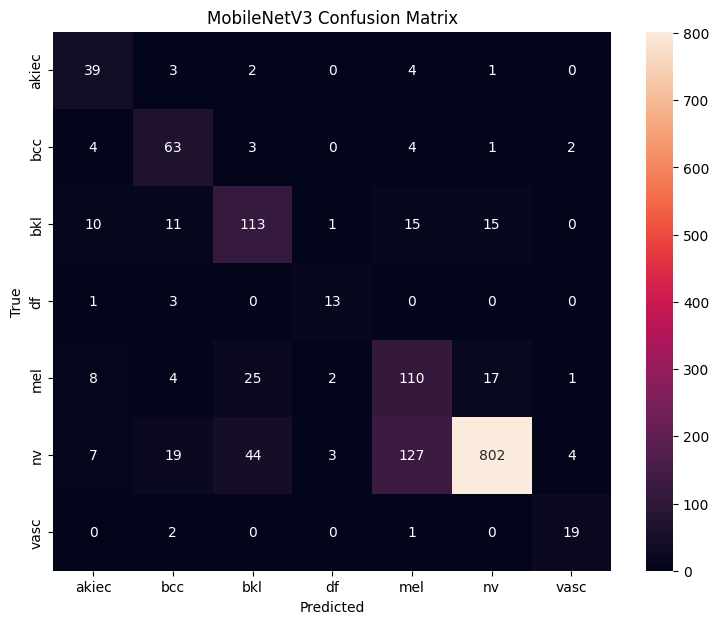


Summary so far:


,model,best_epoch,best_val_macro_f1,best_val_loss,best_epoch_train_macro_f1,best_epoch_val_macro_f1,best_epoch_overfit_gap,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,test_auc_macro,test_auc_micro,checkpoint,history_csv
0,MobileNetV3,18,0.690919,0.855115,0.93274,0.690919,0.241821,0.866244,0.771124,0.699153,0.787218,0.952166,0.966336,/workspace/ham10000_clean_baseline_outputs/Mob...,/workspace/ham10000_clean_baseline_outputs/Mob...


Training: DenseNet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Trainable params during warmup: 7175

DenseNet121 — Epoch 1/18


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>^
^Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()
^  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    ^if w.is_alive():
^ ^  ^ ^  
   File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^
^ ^ ^^  ^  ^ ^
   File "/

  0%|          | 0/47 [00:00<?, ?it/s]

Train Loss: 0.4133 | Acc: 0.9549 | Macro F1: 0.9548
Val   Loss: 0.7180 | Acc: 0.8209 | Macro F1: 0.7471
Overfit Gap: 0.2077 | LR: 3e-05
Patience: 5 / 5
Early stopping.


  0%|          | 0/47 [00:00<?, ?it/s]


FINAL TEST METRICS
Model: DenseNet121
Test Accuracy: 0.8011
Test Macro F1: 0.7025
Test Weighted F1: 0.8131
AUC Macro: 0.9617095712175754
AUC Micro: 0.9714852102551755

Classification Report:
              precision    recall  f1-score   support

       akiec       0.46      0.80      0.59        49
         bcc       0.61      0.82      0.70        77
         bkl       0.59      0.73      0.65       165
          df       0.54      0.76      0.63        17
         mel       0.56      0.65      0.60       167
          nv       0.97      0.83      0.90      1006
        vasc       0.80      0.91      0.85        22

    accuracy                           0.80      1503
   macro avg       0.65      0.79      0.70      1503
weighted avg       0.84      0.80      0.81      1503



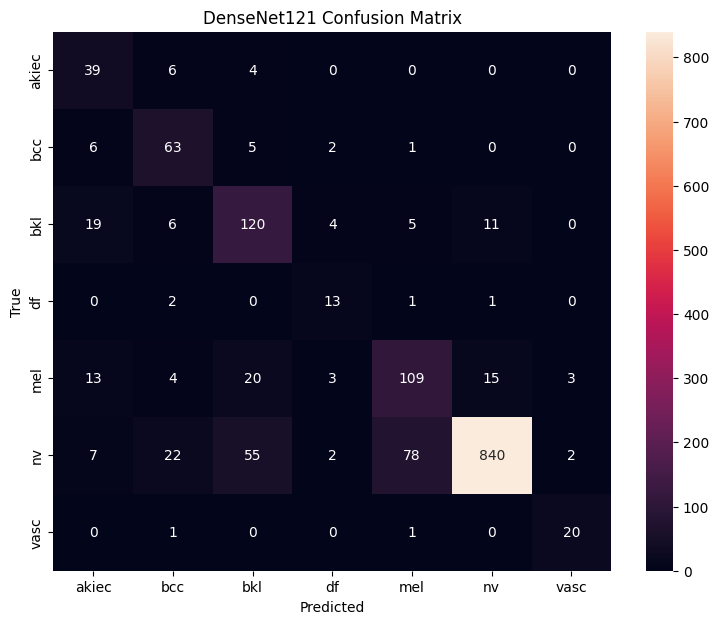


Summary so far:


,model,best_epoch,best_val_macro_f1,best_val_loss,best_epoch_train_macro_f1,best_epoch_val_macro_f1,best_epoch_overfit_gap,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,test_auc_macro,test_auc_micro,checkpoint,history_csv
1,DenseNet121,13,0.759849,0.736189,0.915733,0.759849,0.155884,0.778686,0.801065,0.702483,0.813086,0.961710,0.971485,/workspace/ham10000_clean_baseline_outputs/Den...,/workspace/ham10000_clean_baseline_outputs/Den...
0,MobileNetV3,18,0.690919,0.855115,0.932740,0.690919,0.241821,0.866244,0.771124,0.699153,0.787218,0.952166,0.966336,/workspace/ham10000_clean_baseline_outputs/Mob...,/workspace/ham10000_clean_baseline_outputs/Mob...


Training: ResNet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Trainable params during warmup: 14343

ResNet50 — Epoch 1/18


...

Train Loss: 0.7374 | Acc: 0.8021 | Macro F1: 0.8005
Val   Loss: 0.9013 | Acc: 0.7284 | Macro F1: 0.6263
Overfit Gap: 0.1742 | LR: 1.5e-05
Saved best model: /workspace/ham10000_clean_baseline_outputs/ResNet50_best.pt

ResNet50 — Epoch 16/18


  0%|          | 0/219 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

  0%|          | 0/47 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x77b69e164720>  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

     
if w.is_alive():Traceback (most recent call last):

  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
      self._shutdown_workers() 
   File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
   ^    ^^^if w.is_alive():^
^ ^ ^ ^  ^ ^ ^^^
^  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^  ^ ^ 
   File

In [ ]:

# ============================================================
# Cell 15 — Run 5-Model Comparison
# ============================================================

all_histories = []
all_summaries = []

for config in MODEL_CONFIGS:
    try:
        history_df, summary = train_model(config)

        all_histories.append(history_df)
        all_summaries.append(summary)

        print("\nSummary so far:")
        display(pd.DataFrame(all_summaries).sort_values(by="test_macro_f1", ascending=False))

    except Exception as e:
        print("ERROR training:", config["display"])
        print(e)

        all_summaries.append({
            "model": config["display"],
            "error": str(e)
        })

summary_df = pd.DataFrame(all_summaries)
summary_df


In [ ]:

# ============================================================
# Cell 16 — Final Ranking
# ============================================================

summary_df = pd.DataFrame(all_summaries)

summary_path = OUTPUT_DIR / "clean_5model_summary.csv"
summary_df.to_csv(summary_path, index=False)

if "test_macro_f1" in summary_df.columns:
    ranked_df = summary_df.sort_values(by="test_macro_f1", ascending=False).reset_index(drop=True)
else:
    ranked_df = summary_df

print("Saved summary:", summary_path)

ranked_df


In [ ]:

# ============================================================
# Cell 17 — Curves
# ============================================================

valid_histories = [h for h in all_histories if isinstance(h, pd.DataFrame)]

if len(valid_histories) > 0:
    combined_history = pd.concat(valid_histories, ignore_index=True)

    combined_history_path = OUTPUT_DIR / "clean_5model_all_histories.csv"
    combined_history.to_csv(combined_history_path, index=False)

    plt.figure(figsize=(10, 6))
    for model_name in combined_history["model"].unique():
        sub = combined_history[combined_history["model"] == model_name]
        plt.plot(sub["epoch"], sub["val_macro_f1"], label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel("Validation Macro F1")
    plt.title("Validation Macro F1 Across Models")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    for model_name in combined_history["model"].unique():
        sub = combined_history[combined_history["model"] == model_name]
        plt.plot(sub["epoch"], sub["train_val_macro_f1_gap"], label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel("Train - Validation Macro F1 Gap")
    plt.title("Overfitting Gap Across Models")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Saved combined history:", combined_history_path)
else:
    print("No histories to plot.")


In [ ]:

# ============================================================
# Cell 18 — Best Model
# ============================================================

if "test_macro_f1" in ranked_df.columns:
    best_model_row = ranked_df.iloc[0]

    print("BEST MODEL BASED ON TEST MACRO F1:")
    print(best_model_row["model"])

    display(best_model_row)

    print("\nNext step: optimize ONLY this model.")
else:
    print("No successful model results.")
